In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


In [4]:
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [5]:
df['group'].value_counts()

group
treatment    147276
control      147202
Name: count, dtype: int64

In [6]:
misassigned = df[
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page'))]
misassigned.shape

(3893, 5)

In [7]:
df_clean = df.drop(misassigned.index)

In [8]:
conversion_summary = df_clean.groupby('group')['converted'].agg(['mean','count','sum'])
conversion_summary

,mean,count,sum
group,,,
control,0.120386,145274,17489
treatment,0.118807,145311,17264


In [9]:
conversion_summary['conversion_rate'] = conversion_summary['mean'] * 100
conversion_summary

,mean,count,sum,conversion_rate
group,,,,
control,0.120386,145274,17489,12.038630
treatment,0.118807,145311,17264,11.880725


In [10]:
control_rate = conversion_summary.loc['control','conversion_rate']
treatment_rate = conversion_summary.loc['treatment','conversion_rate']
absolute_diff = treatment_rate - control_rate
relative_diff = (absolute_diff / control_rate) * 100
print("Control:", control_rate)
print("Treatment:", treatment_rate)
print("Absolute diff:", absolute_diff)
print("Relative diff %:", relative_diff)

Control: 12.03863045004612
Treatment: 11.880724790277405
Absolute diff: -0.15790565976871562
Relative diff %: -1.3116580031585792


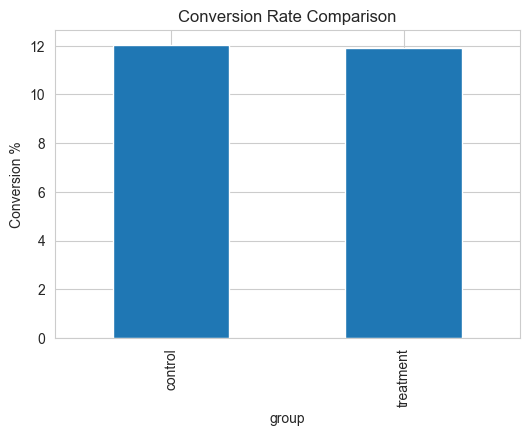

In [11]:
conversion_summary['conversion_rate'].plot(
    kind='bar',
    figsize=(6,4),
    title='Conversion Rate Comparison')
plt.ylabel("Conversion %")
plt.show()

In [13]:
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
daily = df_clean.groupby([
    df_clean['timestamp'].dt.date,'group'
])['converted'].mean().unstack()

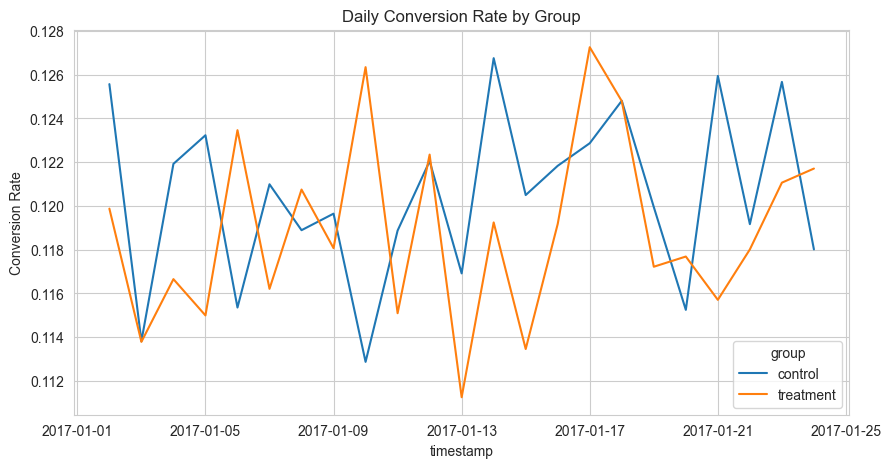

In [15]:
daily.plot(figsize=(10,5))
plt.title("Daily Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.show()

In [16]:
df_clean['hour'] = df_clean['timestamp'].dt.hour
hourly = df_clean.groupby(['hour','group'])['converted'].mean().unstack()

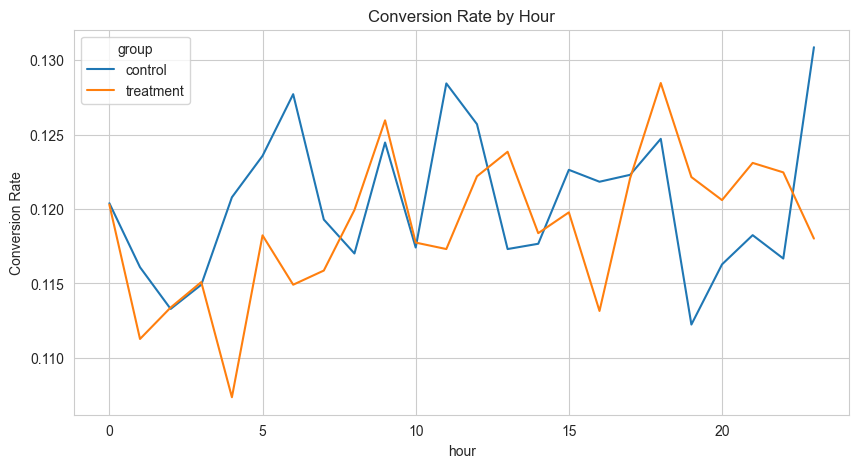

In [ ]:
hourly.plot(figsize=(10,5))
plt.title("Conversion Rate by Hour")
plt.ylabel("Conversion Rate")
plt.show() #bonus

In [19]:
funnel = pd.DataFrame({
    'stage': ['Users', 'Converted'],
    'control': [
        conversion_summary.loc['control','count'],
        conversion_summary.loc['control','sum']
    ],
    'treatment': [
        conversion_summary.loc['treatment','count'],
        conversion_summary.loc['treatment','sum']]
})
funnel

,stage,control,treatment
0,Users,145274,145311
1,Converted,17489,17264


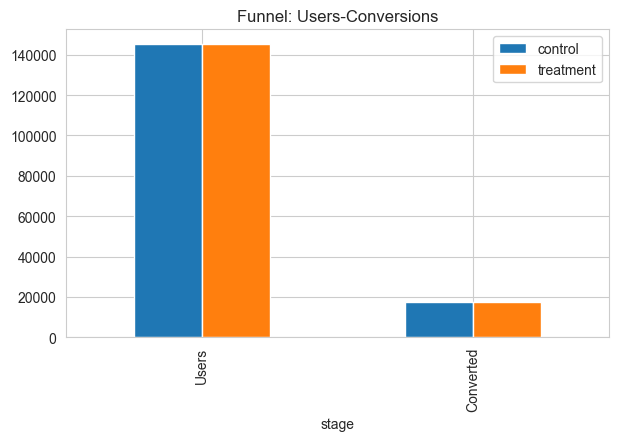

In [21]:
funnel.set_index('stage').plot(
    kind='bar',
    figsize=(7,4))
plt.title("Funnel: Users-Conversions")
plt.show()

In [23]:
print("Control conversion rate:", control_rate)
print("Treatment conversion rate:", treatment_rate)
if treatment_rate > control_rate:
    print("Yeni dizayn daha yaxşıdır - rollout edilə bilər")
else:
    print("Yeni dizayn daha zəifdir - rollout edilməməlidir")

Control conversion rate: 12.03863045004612
Treatment conversion rate: 11.880724790277405
Yeni dizayn daha zəifdir - rollout edilməməlidir


In [27]:
control_rate = 12.04 / 100
treatment_rate = 11.88 / 100
diff = treatment_rate - control_rate
impact_1m = diff * 1_000_000
impact_1m

-1599.9999999999902

In [28]:
print("1M user üçün əlavə konversiya fərqi:", int(impact_1m))

1M user üçün əlavə konversiya fərqi: -1599
